# Analisis Review Aplikasi Netflix di Google Play Store

Notebook ini berisi proses pengambilan data (scraping) review pengguna aplikasi Netflix dari Google Play Store dan dilanjutkan dengan analisis data eksploratif (EDA) untuk memahami feedback pengguna.

In [3]:
!pip install google-play-scraper pandas matplotlib seaborn wordcloud nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1: Data Scraping

Tahap ini melakukan pengambilan data review dari Google Play Store menggunakan library `google-play-scraper`. Kita akan mengambil 100.000 review terbaru dengan menyensor username pengguna demi privasi.

In [7]:
import pandas as pd
import numpy as np
import os
from google_play_scraper import Sort, reviews

# Parameter Scraping
app_id = 'com.netflix.mediaclient'
count = 100000
country = 'us'
lang = 'en'

print("Memulai proses scraping... Mohon tunggu, ini mungkin memakan waktu beberapa menit.")

# Scraping data
result, continuation_token = reviews(
    app_id,
    lang=lang,
    country=country,
    sort=Sort.NEWEST,
    count=count
)

# Buat DataFrame langsung dari list of dicts (result)
df = pd.DataFrame(result)

# Pilih kolom yang diminta
required_columns = ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 
                    'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']
df = df[required_columns]

Memulai proses scraping... Mohon tunggu, ini mungkin memakan waktu beberapa menit.


In [8]:
# Fungsi untuk menyensor username
def censor_username(name):
    if not isinstance(name, str) or len(name) == 0:
        return "***"
    if len(name) <= 2:
        return name[0] + "*"
    return name[0] + "*" * (len(name) - 2) + name[-1]

df['userName'] = df['userName'].apply(censor_username)
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9e918801-fc09-4fbd-b577-c1623b466b18,A***********r,horrible company with an even worse app,1,0,9.59.0 build 8 63972,2026-03-30 21:36:35,None,None,9.59.0 build 8 63972
1,785815e4-2645-473f-85f7-7fd54e375411,A***********r,enjoyed,5,0,NaN,2026-03-30 21:31:29,None,None,NaN
2,68aab1b0-801f-43b4-be84-cab1d9245868,A***********r,संजसद्बुकद्दूक्ष्मस्लास्म,5,0,NaN,2026-03-30 21:27:39,None,None,NaN
3,02467eab-9443-4dba-a415-f367fdf22ab4,A***********r,where is steel ball run netflix? where is it? ...,1,0,NaN,2026-03-30 21:26:51,None,None,NaN
4,9d984e77-9bd9-40ba-a5bb-be3e265b3c81,A***********r,no steel ball run ep2,1,0,9.59.0 build 8 63972,2026-03-30 21:26:39,None,None,9.59.0 build 8 63972


In [9]:
# Pastikan direktori Output tersedia
output_dir = '../Output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Simpan ke CSV
output_file = os.path.join(output_dir, 'Netflix_Review_Raw.csv')
df.to_csv(output_file, index=False)

print(f"Scraping selesai! {len(df)} data telah disimpan ke {output_file}")
df.head()

Scraping selesai! 100000 data telah disimpan ke ../Output\Netflix_Review_Raw.csv


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9e918801-fc09-4fbd-b577-c1623b466b18,A***********r,horrible company with an even worse app,1,0,9.59.0 build 8 63972,2026-03-30 21:36:35,None,None,9.59.0 build 8 63972
1,785815e4-2645-473f-85f7-7fd54e375411,A***********r,enjoyed,5,0,NaN,2026-03-30 21:31:29,None,None,NaN
2,68aab1b0-801f-43b4-be84-cab1d9245868,A***********r,संजसद्बुकद्दूक्ष्मस्लास्म,5,0,NaN,2026-03-30 21:27:39,None,None,NaN
3,02467eab-9443-4dba-a415-f367fdf22ab4,A***********r,where is steel ball run netflix? where is it? ...,1,0,NaN,2026-03-30 21:26:51,None,None,NaN
4,9d984e77-9bd9-40ba-a5bb-be3e265b3c81,A***********r,no steel ball run ep2,1,0,9.59.0 build 8 63972,2026-03-30 21:26:39,None,None,9.59.0 build 8 63972


## Part 2: Data Overview & Quality Check

Mengecek kualitas data, termasuk nilai yang hilang (missing values), tipe data, dan duplikasi.

In [10]:
print("--- Info Dataset ---")
print(df.info())

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              100000 non-null  str           
 1   userName              100000 non-null  str           
 2   content               99999 non-null   str           
 3   score                 100000 non-null  int64         
 4   thumbsUpCount         100000 non-null  int64         
 5   reviewCreatedVersion  72344 non-null   str           
 6   at                    100000 non-null  datetime64[us]
 7   replyContent          0 non-null       object        
 8   repliedAt             0 non-null       object        
 9   appVersion            72344 non-null   str           
dtypes: datetime64[us](1), int64(2), object(2), str(5)
memory usage: 7.6+ MB
None


In [11]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
reviewId                     0
userName                     0
content                      1
score                        0
thumbsUpCount                0
reviewCreatedVersion     27656
at                           0
replyContent            100000
repliedAt               100000
appVersion               27656
dtype: int64


In [12]:
print("\n--- Duplikasi Data ---")
print(f"Jumlah duplikat: {df.duplicated(subset=['reviewId']).sum()}")


--- Duplikasi Data ---
Jumlah duplikat: 0


In [13]:
print("\n--- Deskripsi Statistik ---")
display(df.describe())


--- Deskripsi Statistik ---


,score,thumbsUpCount,at
count,100000.000000,100000.000000,100000
mean,2.956820,4.725860,2025-02-18 02:41:46.786030
min,1.000000,0.000000,2024-03-21 05:05:44
25%,1.000000,0.000000,2024-08-25 00:18:23.500000
50%,3.000000,0.000000,2025-01-25 04:25:43.500000
75%,5.000000,0.000000,2025-08-09 10:00:22
max,5.000000,16632.000000,2026-03-30 21:36:35
std,1.840964,116.660184,NaN


## Part 3: Score Distribution

Visualisasi distribusi rating (skor 1-5).

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26872\1069024196.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


Text(0, 0.5, 'Jumlah')

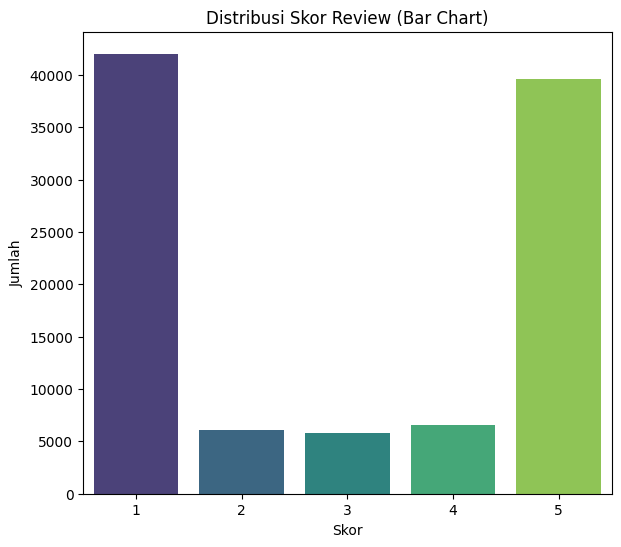

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Bar Chart
plt.subplot(1, 2, 1)
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribusi Skor Review (Bar Chart)')
plt.xlabel('Skor')
plt.ylabel('Jumlah')

Text(0, 0.5, '')

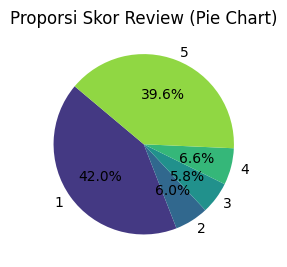

In [15]:
# Pie Chart
plt.subplot(1, 2, 2)
df['score'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 5))
plt.title('Proporsi Skor Review (Pie Chart)')
plt.ylabel('')

In [16]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Part 4: Temporal Analysis

Menganalisis tren volume review dan skor dari waktu ke waktu.

Text(0, 0.5, 'Jumlah Review')

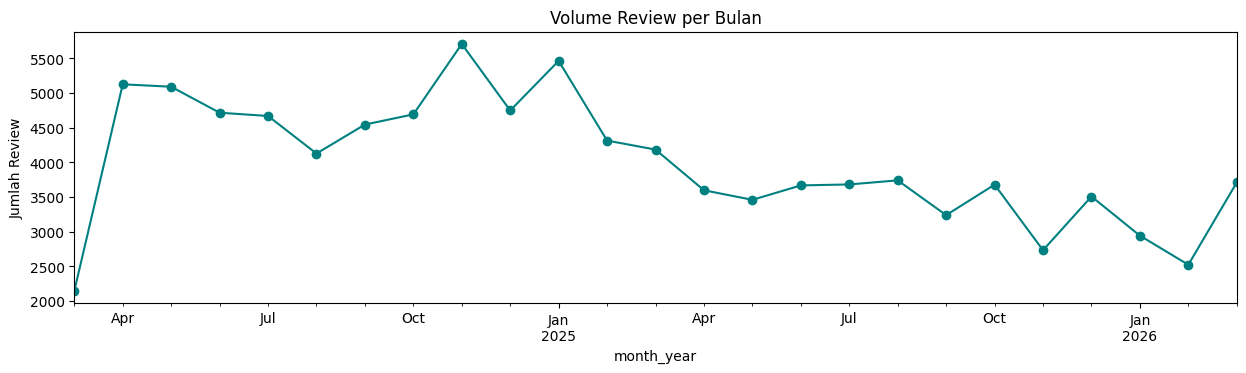

In [17]:
# Konversi kolom waktu
df['at'] = pd.to_datetime(df['at'])
df['month_year'] = df['at'].dt.to_period('M')

plt.figure(figsize=(15, 12))

# 1. Volume Review per Bulan
plt.subplot(3, 1, 1)
df.groupby('month_year').size().plot(kind='line', marker='o', color='teal')
plt.title('Volume Review per Bulan')
plt.ylabel('Jumlah Review')


Text(0, 0.5, 'Rata-rata Skor')

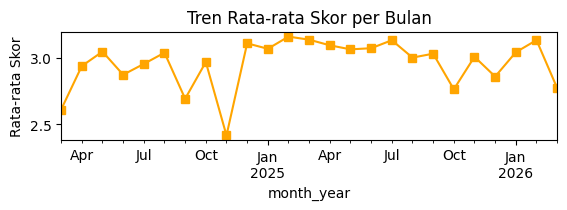

In [18]:
# 2. Tren Rata-rata Skor
plt.subplot(3, 1, 2)
df.groupby('month_year')['score'].mean().plot(kind='line', marker='s', color='orange')
plt.title('Tren Rata-rata Skor per Bulan')
plt.ylabel('Rata-rata Skor')

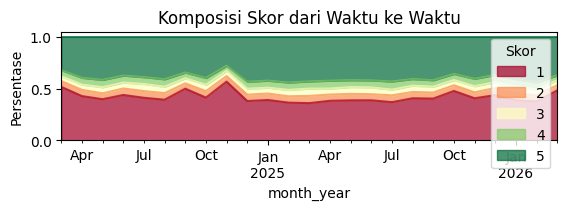

In [19]:
# 3. Komposisi Skor (Stacked Area Chart)
plt.subplot(3, 1, 3)
pivot_df = df.groupby(['month_year', 'score']).size().unstack(fill_value=0)
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0)
pivot_df_perc.plot(kind='area', stacked=True, ax=plt.gca(), cmap='RdYlGn', alpha=0.7)
plt.title('Komposisi Skor dari Waktu ke Waktu')
plt.ylabel('Persentase')
plt.legend(title='Skor', loc='upper right')

In [20]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Part 5: Text Analysis

Menganalisis panjang teks review dan kata-kata yang sering muncul.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


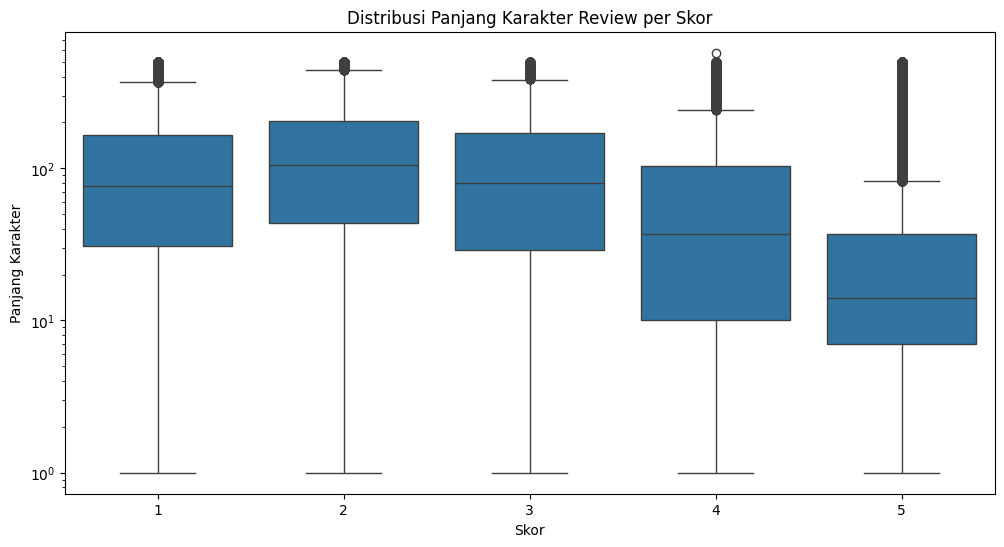

Sedang memproses teks untuk Word Cloud...


In [21]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Distribusi Panjang Review per Skor
df['review_len'] = df['content'].apply(lambda x: len(str(x)))
plt.figure(figsize=(12, 6))
sns.boxplot(x='score', y='review_len', data=df)
plt.title('Distribusi Panjang Karakter Review per Skor')
plt.xlabel('Skor')
plt.ylabel('Panjang Karakter')
plt.yscale('log')
plt.show()

# Fungsi pembersihan teks sederhana
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

print("Sedang memproses teks untuk Word Cloud...")

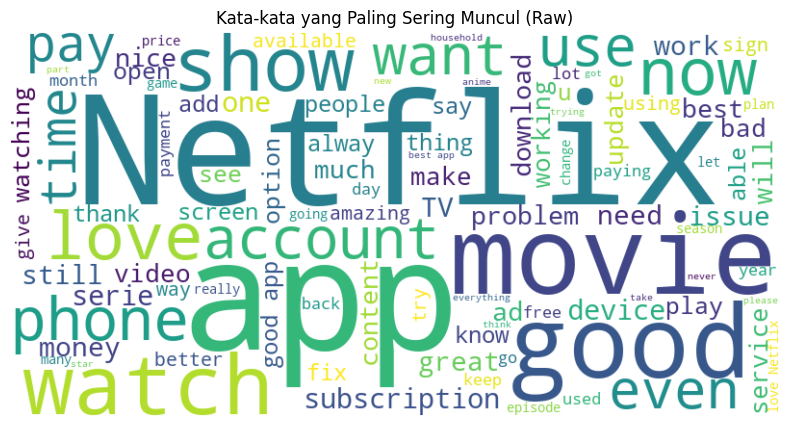

In [ ]:
# 2. Word Cloud Umum (Raw)                                                                 
all_text_raw = ' '.join(df['content'].dropna().astype(str))                                                      
if all_text_raw:                                                                                                         
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text_raw)                
    plt.figure(figsize=(10, 5))                                                                                        
    plt.imshow(wc, interpolation='bilinear')                                                                           
    plt.axis('off')                                                                                                    
    plt.title('Kata-kata yang Paling Sering Muncul (Raw)')   

    plt.show()                                                                                                                    

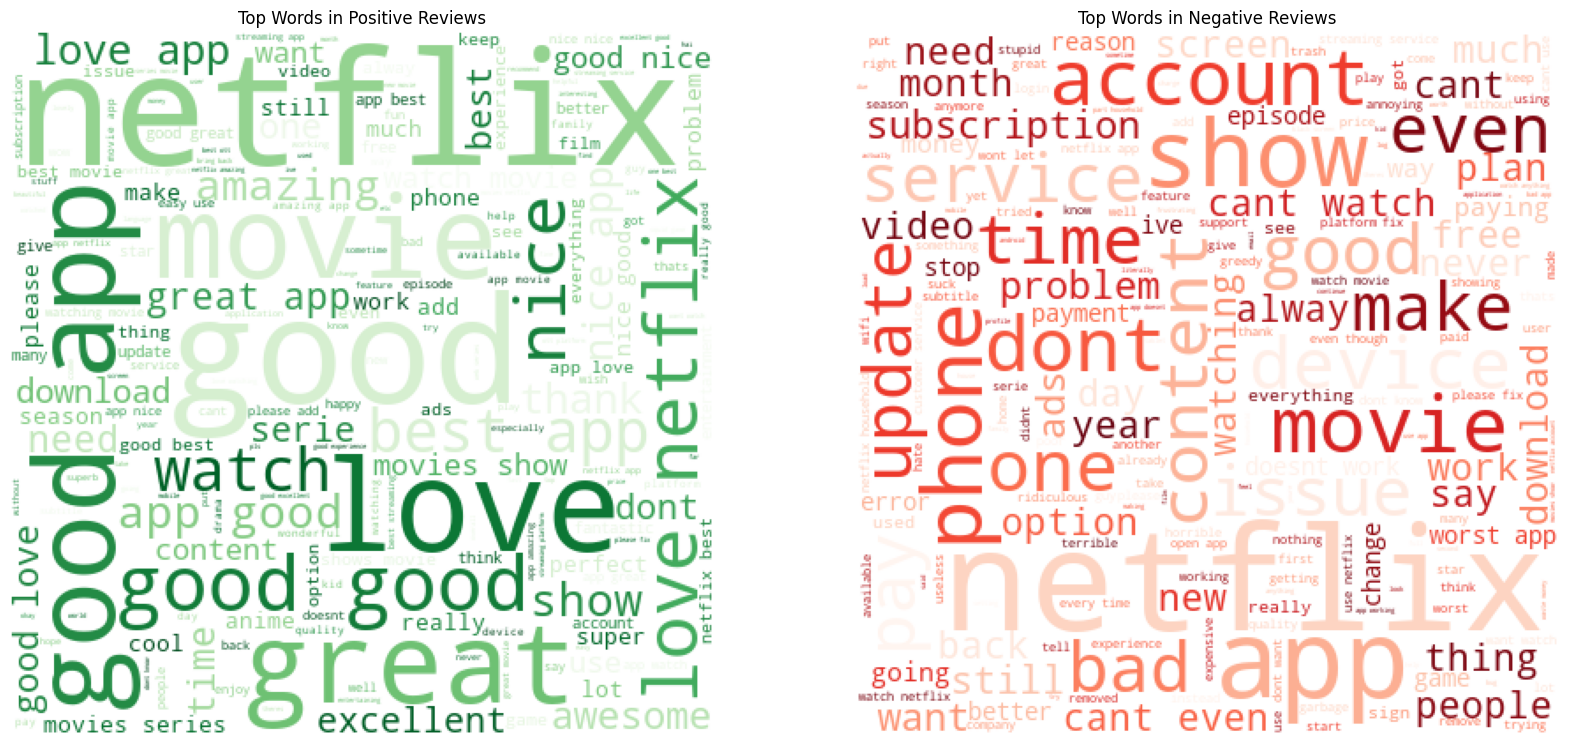

In [23]:
# 3. Perbandingan Positif (4-5) vs Negatif (1-2)
pos_text = " ".join(df[df['score'] >= 4]['content'].apply(clean_text))
neg_text = " ".join(df[df['score'] <= 2]['content'].apply(clean_text))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

wc_pos = WordCloud(width=400, height=400, background_color='white', colormap='Greens').generate(pos_text)
ax1.imshow(wc_pos)
ax1.set_title('Top Words in Positive Reviews')
ax1.axis('off')

wc_neg = WordCloud(width=400, height=400, background_color='white', colormap='Reds').generate(neg_text)
ax2.imshow(wc_neg)
ax2.set_title('Top Words in Negative Reviews')
ax2.axis('off')

plt.show()

## Part 6: App Version Analysis

Melihat performa aplikasi berdasarkan versi yang digunakan pengguna.

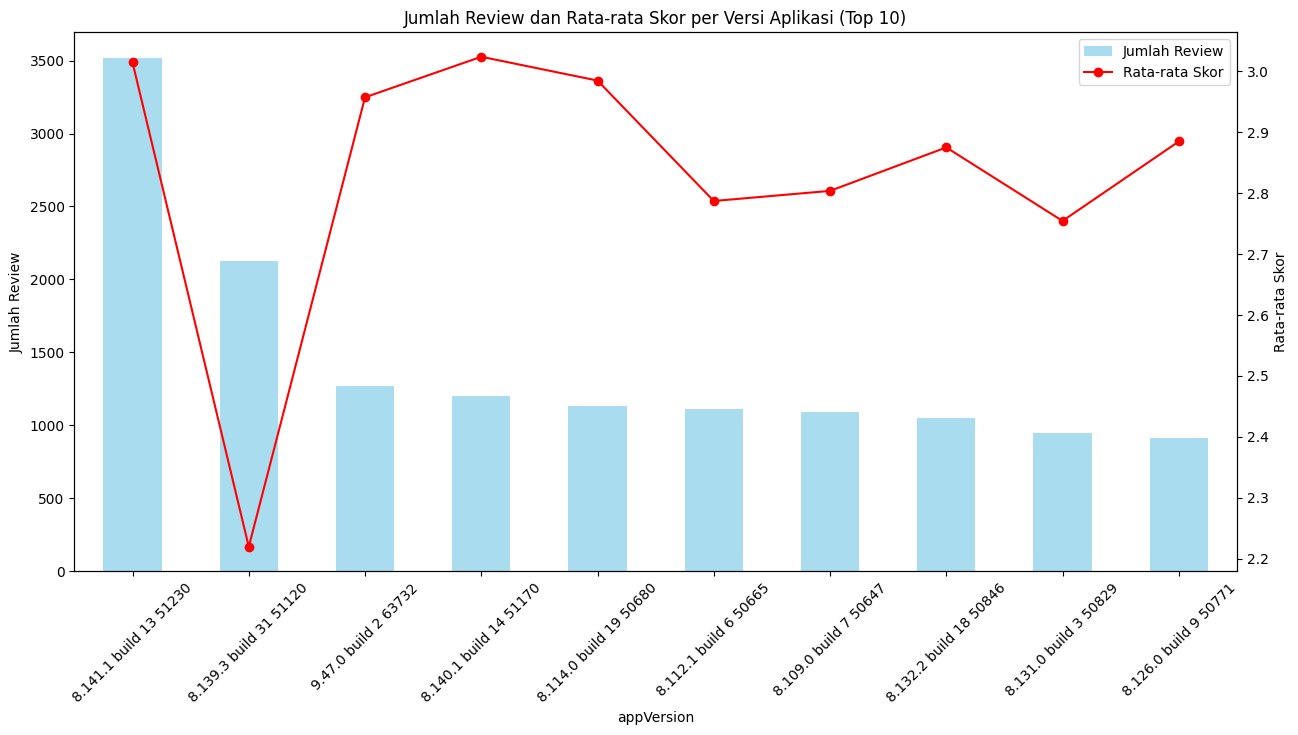

In [24]:
# Mengambil 10 versi teratas dengan review terbanyak
top_versions = df['appVersion'].value_counts().nlargest(10).index
df_versions = df[df['appVersion'].isin(top_versions)]

version_stats = df_versions.groupby('appVersion').agg({
    'score': 'mean',
    'reviewId': 'count'
}).rename(columns={'reviewId': 'count'}).sort_values('count', ascending=False)

fig, ax1 = plt.subplots(figsize=(15, 7))

ax2 = ax1.twinx()
version_stats['count'].plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7, label='Jumlah Review')
version_stats['score'].plot(kind='line', ax=ax2, color='red', marker='o', label='Rata-rata Skor')

ax1.set_ylabel('Jumlah Review')
ax2.set_ylabel('Rata-rata Skor')
ax1.set_title('Jumlah Review dan Rata-rata Skor per Versi Aplikasi (Top 10)')
ax1.set_xticklabels(version_stats.index, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()